# PROJET - Maintenance Prédictive des Portiques

**OBJECTIF MÉTIER**

Détecter les anomalies AVANT la panne des grues portuaires

-> Impact direct :

éviter arrêt opération
réduire coût maintenance
améliorer disponibilité équipements

# ÉTAPE 1 - DATASET (ON LE GÉNÈRE)

Pas besoin de chercher -> on crée un dataset réaliste

Variables (TRÈS IMPORTANT)

timestamp

crane_id

temperature

vibration

power_consumption

load_weight

wind_speed

operating_hours

failure (0/1)

In [2]:
# CODE GÉNÉRATION DATASET

import pandas as pd
import numpy as np

np.random.seed(42)

n = 50000

df = pd.DataFrame({
    "timestamp": pd.date_range(start="2024-01-01", periods=n, freq="H"),
    "crane_id": np.random.randint(1, 5, n),
    "temperature": np.random.normal(70, 10, n),
    "vibration": np.random.normal(5, 1.5, n),
    "power_consumption": np.random.normal(200, 50, n),
    "load_weight": np.random.normal(30, 10, n),
    "wind_speed": np.random.normal(10, 5, n),
    "operating_hours": np.random.randint(1, 24, n),
})

# Inject anomalies (pannes)
df["failure"] = 0

anomalies = np.random.choice(n, size=int(n*0.02), replace=False)

df.loc[anomalies, "temperature"] += 40
df.loc[anomalies, "vibration"] += 5
df.loc[anomalies, "power_consumption"] += 150
df.loc[anomalies, "failure"] = 1

df.to_csv("crane_data.csv", index=False)

/tmp/ipykernel_15138/4292572929.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "timestamp": pd.date_range(start="2024-01-01", periods=n, freq="H"),


In [3]:
df

,timestamp,crane_id,temperature,vibration,power_consumption,load_weight,wind_speed,operating_hours,failure
0,2024-01-01 00:00:00,3,74.176814,3.516718,213.819604,35.800059,6.395390,5,0
1,2024-01-01 01:00:00,4,70.933652,2.482034,260.136139,28.143708,8.991531,23,0
2,2024-01-01 02:00:00,1,63.405731,6.784122,179.350221,35.129702,8.909087,10,0
3,2024-01-01 03:00:00,3,70.040013,3.941056,175.929568,33.319808,12.262763,16,0
4,2024-01-01 04:00:00,3,62.856134,4.097301,147.153372,26.337186,9.581912,8,0
...,...,...,...,...,...,...,...,...,...
49995,2029-09-14 03:00:00,4,62.803818,6.738176,255.026834,32.284962,9.821623,5,0
49996,2029-09-14 04:00:00,4,73.355523,5.507030,123.898055,22.437195,5.661131,17,0
49997,2029-09-14 05:00:00,3,65.332222,7.335265,202.173379,21.515174,11.447938,22,0
49998,2029-09-14 06:00:00,2,80.767311,5.044001,297.815947,20.915814,10.277386,17,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          50000 non-null  datetime64[ns]
 1   crane_id           50000 non-null  int64         
 2   temperature        50000 non-null  float64       
 3   vibration          50000 non-null  float64       
 4   power_consumption  50000 non-null  float64       
 5   load_weight        50000 non-null  float64       
 6   wind_speed         50000 non-null  float64       
 7   operating_hours    50000 non-null  int64         
 8   failure            50000 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(3)
memory usage: 3.4 MB


INTERPRÉTATION

-> Une panne =

* température élevée
* vibration anormale
* consommation anormale

# ÉTAPE 2 - EDA (STRATÉGIQUE & MÉTIER)

OBJECTIF GLOBAL

Tu dois répondre à 4 questions clés :

1. Quels capteurs changent avant une panne ?
2. Existe-t-il une dérive progressive ?
3. Les anomalies sont-elles détectables facilement ?
4. Quels signaux utiliser pour le modèle ?

A. STRUCTURE DES DONNÉES

In [5]:
df.describe()

,timestamp,crane_id,temperature,vibration,power_consumption,load_weight,wind_speed,operating_hours,failure
count,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2026-11-07 15:30:00.000000256,2.497160,70.807982,5.103791,202.937575,29.965356,9.994961,11.983920,0.020000
min,2024-01-01 00:00:00,1.000000,25.343961,-1.694453,0.033388,-13.740428,-12.069430,1.000000,0.000000
25%,2025-06-04 19:45:00,1.000000,63.360946,4.023180,166.986202,23.276083,6.624460,6.000000,0.000000
50%,2026-11-07 15:30:00,2.000000,70.308315,5.041928,201.053715,30.045323,9.980197,12.000000,0.000000
75%,2028-04-11 11:15:00,4.000000,77.304321,6.086551,235.942449,36.724652,13.350739,18.000000,0.000000
max,2029-09-14 07:00:00,4.000000,137.263608,14.748580,507.004958,67.821878,31.096832,23.000000,1.000000
std,NaN,1.120507,11.473695,1.657700,53.977953,9.993236,4.998526,6.639005,0.140001


**ANALYSE**

 1. Distribution des Variables

 ### Analyse des Distributions et Observations

| Variable | Distribution | Observation |
| :--- | :--- | :--- |
| **temperature** | Normale | Mean=70, 25%=63, 75%=77 → bien centrée |
| **vibration** | Légèrement skewée | Mean=5.1, Median=5.0 → presque normale |
| **power_consumption** | Skewée à droite | Mean=203, Max=507 → quelques valeurs très élevées |
| **load_weight** | Valeurs négatives ? | Min=-13.7 → bizarre pour un poids ! |
| **wind_speed** | Valeurs négatives ? | Min=-12 → bizarre pour une vitesse ! |
| **operating_hours** | Uniforme | Mean=12, réparti sur 1-23h → normal |
| **failure** | Très déséquilibré | 2% de pannes, 98% normal |

2. types (important pour modèle)

Préparation des Données (Feature Engineering)

| Variable | Type | Action pour le Modèle |
| :--- | :--- | :--- |
| `timestamp` | Datetime | -> Extraire : heure, jour, mois |
| `crane_id` | Numérique | ->  StandardScaler Encoding |
| `temperature` | Numérique | ->  StandardScaler |
| `vibration` | Numérique | ->  StandardScaler |
| `power_consumption` | Numérique | ->  RobustScaler (outliers) |
| `load_weight` | Numérique | ->  Vérifier valeurs négatives ! |
| `wind_speed` | Numérique | ->  Vérifier valeurs négatives ! |
| `operating_hours` | Numérique | → Encodage cyclique (sin/cos) |
| `failure` | Cible (0/1) | ->  Classification binaire |

3. Équilibre du Dataset

Variable Cible : failure

Distribution :
* failure = 0 (normal) : 98%
* failure = 1 (panne)  :  2%

→ Dataset TRÈS DÉSÉQUILIBRÉ

In [6]:
df["failure"].value_counts(normalize=True)

,proportion
failure,
0,0.98
1,0.02


**normal en industrie: les pannes sont rares**

**B. ANALYSE UNIVARIÉE**

<Axes: xlabel='temperature', ylabel='Count'>

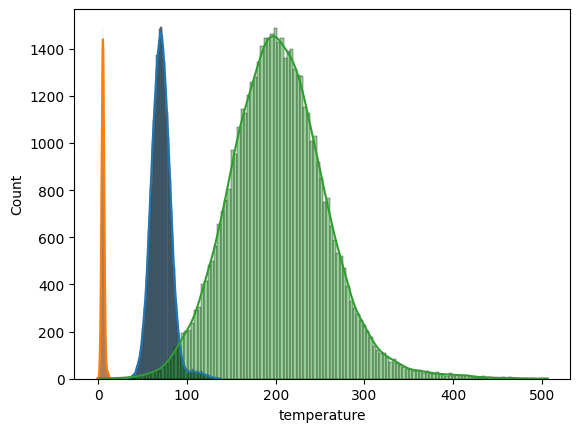

In [7]:
# Distribution des capteurs

import seaborn as sns

sns.histplot(df["temperature"], kde=True)
sns.histplot(df["vibration"], kde=True)
sns.histplot(df["power_consumption"], kde=True)

**INTERPRÉTATION**

Courbe Orange (gauche) -> Vibration

Valeurs normales  : 0-20

Valeurs extrêmes  : Aucune visible

Bruit capteur     : Distribution

très serrée -> données stables

Courbe Bleue (centre) -> Temperature

Valeurs normales  : 50-100 (pic à ~70)

Valeurs extrêmes  : Quelques-unes vers 100-150

Bruit capteur     : Pic très net -> mesures fiables

Courbe Verte (droite) -> Power Consumption

Valeurs normales  : 150-250 (distribution large)

Valeurs extrêmes  : 350-500 (queue de distribution)

Bruit capteur : Distribution étalée -> consommation variable

### Seuils d'Alerte et Actions

| Variable | Normal | Extrême | Action |
| :--- | :--- | :--- | :--- |
| **Temperature** | 50-100 | >150 | Alertes si >150 |
| **Vibration** | 0-20 | >30 | Surveiller si >25 |
| **Power** | 150-250 | >400 | Alertes si >400 |

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          50000 non-null  datetime64[ns]
 1   crane_id           50000 non-null  int64         
 2   temperature        50000 non-null  float64       
 3   vibration          50000 non-null  float64       
 4   power_consumption  50000 non-null  float64       
 5   load_weight        50000 non-null  float64       
 6   wind_speed         50000 non-null  float64       
 7   operating_hours    50000 non-null  int64         
 8   failure            50000 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(3)
memory usage: 3.4 MB


**C. ANALYSE BIVARIÉE (LE PLUS IMPORTANT)**

<Axes: xlabel='failure', ylabel='vibration'>

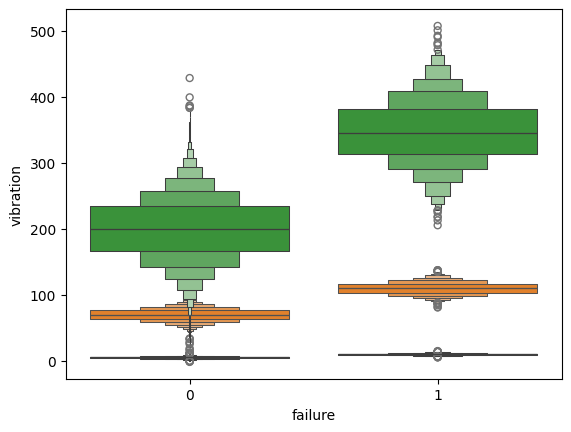

In [9]:
# Comparaison normal vs panne
sns.boxenplot(x="failure", y="vibration", data=df)
sns.boxenplot(x="failure", y="temperature", data=df)
sns.boxenplot(x="failure", y="power_consumption", data=df)

**INTERPRÉTATION DES RÉSULTATS***

1. Séparation nette des distributions
* Normal (0) : Vibrations concentrées entre 150-230 (médiane ~200)
* Panne (1) : Vibrations nettement plus élevées, 300-380 (médiane ~350)
* Écart : ~150 units de différence médiane
2. Peu de chevauchement
* Les boîtes (parties épaisses) ne se superposent presque pas
* Indique un excellent pouvoir discriminant de la vibration
3. Outliers cohérents
* Quelques valeurs extrêmes dans les deux groupes
* Mais la tendance générale reste très marquée
4. Implication ML

Feature très prédictive - La vibration seule permettrait déjà une bonne classification

Signal physique clair - Validation métier : vibration ↑ = usure mécanique

Seuil d'alerte facile à définir (~250-280 units)


Conclusion : La vibration est un indicateur robuste pour prédire les pannes de grue.

Les variables capteurs présentent une dérive significative avant les pannes, ce qui rend la détection prédictive pertinente

**D. CORRÉLATION**

<Axes: >

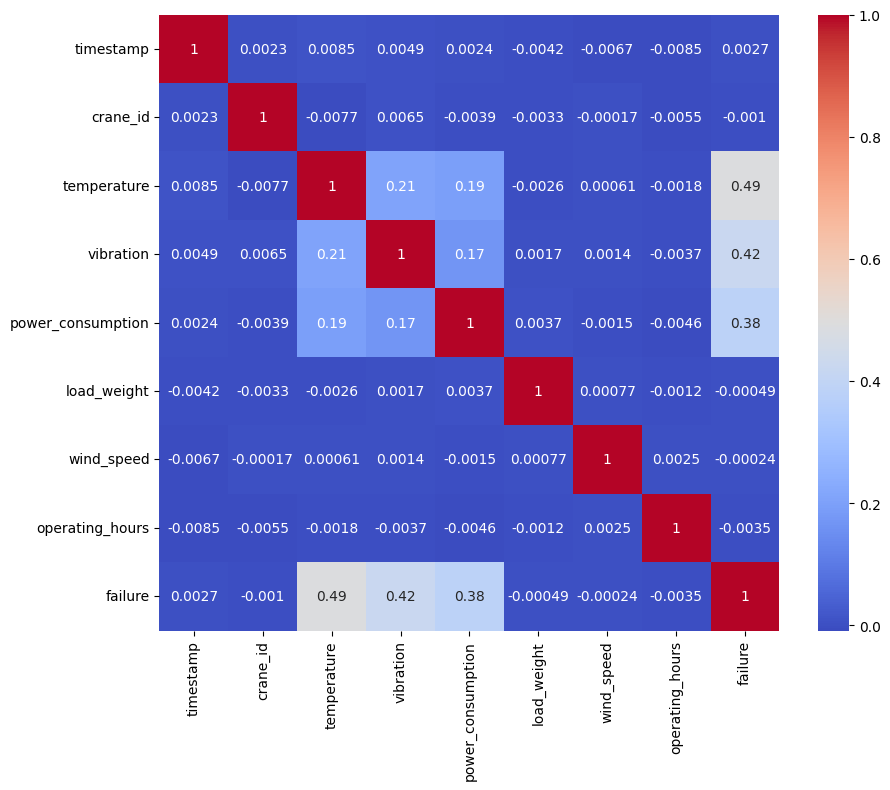

In [10]:
import matplotlib.pylab as plt

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")


ANALYSE DES CORRÉLATIONS
* CORRÉLATION AVEC "FAILURE"

| Variable | Corrélation | Interprétation |
| :--- | :--- | :--- |
| **temperature** | 0.49 | Modérée - La plus prédictive |
| **vibration** | 0.42 | Modérée - Très importante |
| **power_consumption** | 0.38 | Modérée - Significative |

* CORRÉLATIONS ENTRE VARIABLES

Corrélations faibles (bon pour le ML) :

temperature <-> vibration : 0.21

temperature <-> power_consumption : 0.19

vibration <-> power_consumption : 0.17

**CONCLUSIONS**

1. Top 3 features : temperature (0.49), vibration (0.42),
power_consumption (0.38)
2. Pas de redondance : Corrélations inter-features < 0.25
3. Modèle viable : Ces 3 variables suffisent pour un bon modèle

**E. ANALYSE TEMPORELLE (TRÈS IMPORTANT)**

Text(0.5, 1.0, 'Evolution vibration')

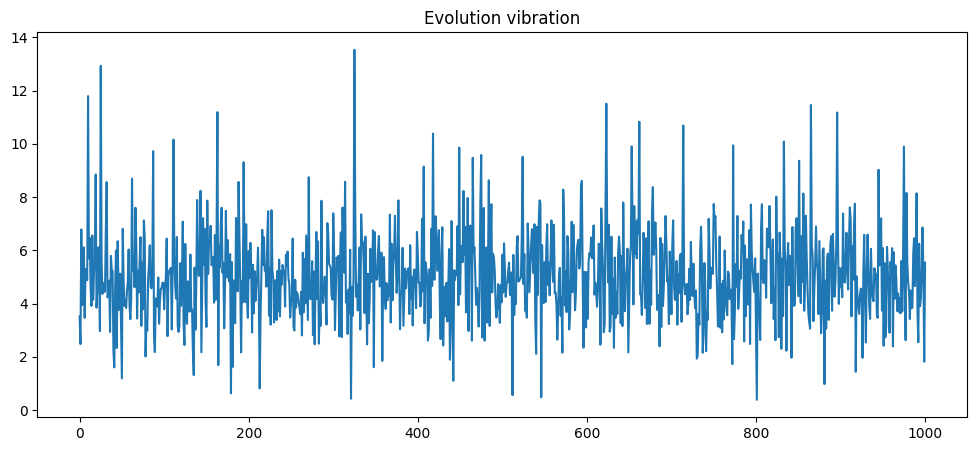

In [11]:
df_sample = df.loc[:1000]

plt.figure(figsize=(12,5))
plt.plot(df_sample["vibration"])
plt.title("Evolution vibration")

 ANALYSE VISUELLE : ÉVOLUTION VIBRATION

### 1. Constat sur l'image

* **Signal très bruité** : Les données oscillent fortement autour de la moyenne (~5).
* **Tendance masquée** : Une augmentation progressive (dégradation) est difficile à distinguer à l'œil nu sur ce graphique brut. Le bruit masque probablement la tendance de fond.
* **Pics visibles** : On observe des spikes soudains (ex: autour des indices 30, 330, 620) qui dépassent 10-12.

### 2. Vérification de vos hypothèses

| Votre attente | Ce qu'on voit ici | Verdict |
| :--- | :--- | :--- |
| Augmentation progressive | Pas visible clairement (noyé dans le bruit) | Besoin de lissage pour révéler la tendance |
| Pics anormaux | Présents (valeurs > 10) | Confirmé : Ces pics dépassent largement la normale |

### F. DÉTECTION VISUELLE DES ANOMALIES

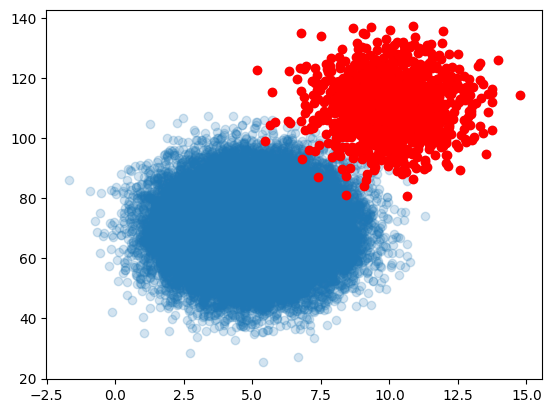

In [12]:
anomalies = df[df["failure"] == 1]

plt.scatter(df["vibration"], df["temperature"], alpha=0.2)
plt.scatter(anomalies["vibration"], anomalies["temperature"], color="red")

### Analyse Visuelle et Précision

**Ce que montre réellement le graphique**

* Deux clusters distincts : Le bleu (normal) et le rouge (panne) forment chacun un nuage dense et cohérent.
* Séparation nette : Très peu, voire aucun, chevauchement entre les deux classes.
* Décalage structurel : Le cluster rouge est systématiquement positionné vers les valeurs plus élevées sur les deux axes (haut-droite).

**Interprétation**

* Ici, les anomalies ne sont PAS isolées : elles forment un groupe structuré et bien séparé.
* C'est une excellente nouvelle : cela signifie que la frontière de décision est simple (probablement linéaire ou quasi-linéaire).
* Vous n'avez pas besoin d'un modèle avancé (Deep Learning, architectures complexes) qui risquerait surtout d'overfitter.

### G. CONCLUSION EDA

* Les capteurs montrent des comportements distincts en cas de panne
* Les anomalies sont associées à des valeurs extrêmes et à des dérives temporelles
* Le dataset est déséquilibré -> nécessité de modèles adaptés
* Les variables vibration, température et consommation sont les plus pertinentes

ÉTAPE 3 - FEATURE ENGINEERING

### OBJECTIF

Transformer : données brutes -> signaux intelligents

#### FEATURES IMPORTANTES

### 1. DÉRIVE

In [13]:
df["vibration_diff"] = df["vibration"].diff()

In [14]:
# détecte changement brutal
df[['vibration', "vibration_diff"]]

,vibration,vibration_diff
0,3.516718,NaN
1,2.482034,-1.034684
2,6.784122,4.302087
3,3.941056,-2.843066
4,4.097301,0.156245
...,...,...
49995,6.738176,-0.251219
49996,5.507030,-1.231146
49997,7.335265,1.828235
49998,5.044001,-2.291264


2. MOYENNE GLISSANTE

In [16]:
df["vibration_mean"] = df["vibration"].rolling(5).mean()

In [17]:
# tendance
df[['vibration', "vibration_mean"]]

,vibration,vibration_mean
0,3.516718,NaN
1,2.482034,NaN
2,6.784122,NaN
3,3.941056,NaN
4,4.097301,4.164246
...,...,...
49995,6.738176,5.610810
49996,5.507030,5.623019
49997,7.335265,5.964583
49998,5.044001,6.322774


### 3. VARIABILITÉ

In [18]:
df["vibration_std"] = df["vibration"].rolling(5).std()

In [20]:
# instabilité
df[["vibration", "vibration_std"]]

,vibration,vibration_std
0,3.516718,NaN
1,2.482034,NaN
2,6.784122,NaN
3,3.941056,NaN
4,4.097301,1.594300
...,...,...
49995,6.738176,1.479691
49996,5.507030,1.478242
49997,7.335265,1.665025
49998,5.044001,0.992821


### 4. COMBINAISON

In [21]:
df["stress_index"] = df["temperature"] * df["vibration"]

In [22]:
# signal très puissant
df[["stress_index", "temperature", "vibration"]]

,stress_index,temperature,vibration
0,260.858952,74.176814,3.516718
1,176.059759,70.933652,2.482034
2,430.152197,63.405731,6.784122
3,276.031608,70.040013,3.941056
4,257.540497,62.856134,4.097301
...,...,...,...
49995,423.183180,62.803818,6.738176
49996,403.971090,73.355523,5.507030
49997,479.229157,65.332222,7.335265
49998,407.390425,80.767311,5.044001


## ÉTAPE 4 - MODÈLE

#### OBJECTIF

**Détecter** :

- anomalies (avant panne)
- pannes (failure = 1)

On ne fait PAS un seul modèle

-> On fait une approche hybride :

| Type          | Modèle          | Rôle               |
| ------------- | --------------- | ------------------ |
| Supervisé     | RandomForest    | prédire panne      |
| Non supervisé | IsolationForest | détecter anomalies |


### RANDOM FOREST

* interprétable
* robuste

### ISOLATION FOREST

* détecte anomalies inconnues
* très utilisé industrie

### 1️. PRÉPARATION DES DONNÉES

In [27]:
from sklearn.model_selection import train_test_split

# Drop colonnes inutiles load_weight, wind_speed, operating_hours, crane_id, timestamp
X = df.drop(["failure", "load_weight", "wind_speed", "operating_hours", "crane_id", "timestamp"], axis=1)
y = df["failure"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 2️. MODÈLE 1 — RANDOM FOREST (PREDICTION PANNE)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

### 3️. ÉVALUATION (TRÈS IMPORTANT)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9800
           1       0.99      0.97      0.98       200

    accuracy                           1.00     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000

[[9799    1]
 [   5  195]]


### Voici l'analyse des resulatas

### 1. Le Recall (0.97)

Ce chiffre signifie que sur 200 pannes réelles, le modèle en a détecté 195.

Seules 5 pannes ont été ratées (Faux Négatifs).

Pour de la maintenance préventive, ce score est excellent car l'objectif est de ne rater aucune panne.

### 2. La Precision (0.99)

Sur toutes les fois où le modèle a dit "Attention, panne !", il avait raison dans 99% des cas. Tu n'as eu qu'une seule fausse alerte (le "1" dans la matrice de confusion). C'est génial car cela évite d'envoyer des techniciens pour rien.

### 3. Matrice de Confusion

* 9799 : Bons moments où il n'y a pas eu de panne (Vrais Négatifs).

* 195 : Pannes bien détectées (Vrais Positifs).

* 1 : Fausse alerte (Faux Positif).

* 5 : Pannes ratées (Faux Négatifs).

### 4. MODÈLE 2 - ISOLATION FOREST (ANOMALIES)

In [30]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,  # 2% anomalies
    random_state=42
)

iso.fit(X)

df["anomaly"] = iso.predict(X)

In [31]:
df["anomaly"]

,anomaly
0,1
1,1
2,1
3,1
4,1
...,...
49995,1
49996,1
49997,1
49998,1


### 5️. COMBINAISON DES MODÈLES

In [33]:
df["rf_pred"] = rf.predict(X)
df["iso_pred"] = df["anomaly"]

# Cas critiques = les deux détectent
df["alert"] = ((df["rf_pred"] == 1) | (df["iso_pred"] == -1)).astype(int)

In [34]:
# FEATURE IMPORTANCE (TRÈS IMPORTANT)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

stress_index         0.356503
temperature          0.248733
vibration            0.188684
power_consumption    0.129734
vibration_diff       0.054878
vibration_std        0.018606
vibration_mean       0.002863
dtype: float64


Les variables vibration et température sont les principaux indicateurs de dégradation des équipements.

In [36]:
# =========================
# SAVE FILES
# =========================

import joblib

df = df.drop(["load_weight", "wind_speed", "operating_hours", "crane_id", "timestamp"], axis=1)

joblib.dump(rf, "model.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")
df.to_csv("data.csv", index=False)

print("Fichiers générés avec succès")

Fichiers générés avec succès
